Logistic Regression:


Contributions:
1. https://www.ibm.com/think/topics/logistic-regression
2. https://www.analyticsvidhya.com/blog/2023/01/a-comprehensive-guide-to-ols-regression-part-1/

In [1]:
# Libraries:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from itertools import combinations
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score,
    f1_score, recall_score, precision_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Data import and pre-processing:

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_features = pd.read_csv("top50_features.csv", parse_dates=['Date'])
df_features = df_features.set_index('Date')


data = pd.concat([df_features,df_factor], axis=1, join='inner')
data = data.dropna()

print(data.columns)

Index(['GlobalBondGret1', 'USDZARVol1', 'LocalPropertyVol3',
       'BCMPUSIF.Index_QS', 'LA1RollKurt', 'LA1StructBreak', 'GLD_RollSkew',
       'JALSH_RV_12_TS', 'VixMoveSpread',
       'JALSH.Index.PE.Ratio.Next.FY.Aggregated_Diff', 'BCMPUSGR.Index_QS',
       'AAIIBULL.Index', 'USDZARSB', 'DXY_TS', 'TOP40.Index.PE.Ratio_Diff',
       'GlobalBondTS', 'SA_NB_Level_TS', 'USRealBndStructBreak_Slope',
       'TOP40.Index.Forward.PE_Diff', 'SANomBndStructBreak_Slope',
       'LocalEquityTS', 'JALSH.Index.Price.to.Sales.Ratio_QS', 'US_NB_R2_QS',
       'US_NB_Level_QS', 'MXWD_PEvAgrgtPE_1FY', 'LA1RollSkew',
       'VolTermStructPC1', 'BCMPEBLS.Index_QS',
       'MXWD.Index.Price.to.Ebitda_Diff', 'AAIIBEAR.Index_QS',
       'HG1.Comdty_Diff_QS', 'USNomBndStructBreak_Slope', 'USDZAR_Ent',
       'SA_NB_Level', 'LocalBonds_Ent', 'LocalBonds_EntDyn', 'USDZARGret1',
       'GlobalBondVol1', 'US_RB_Slope_TS', 'US_NB_Level', 'GenComIndexPC2',
       'MXWD.Index.PE.Ratio_QS', 'WOG1_Ent_TS', 'USDZA

In [3]:


# ===========================================================
# Logistic Regression Model - custom gradient descent 
# (I'm not entirely confortable with how scikit learn adjusts the learning rate in their logistic regression custom model)
# We used this model in the Data analytics course
# ===========================================================
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tol = tol
        self.beta = None
        self.cost_history = []
    
    def sigmoid(self, z):
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))
    
    def cost_function(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        h = np.clip(h, 1e-10, 1 - 1e-10)
        return (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))
    
    def gradient_descent(self, X, y, beta):
        m = len(y)
        for i in range(self.num_iterations):
            h = self.sigmoid(X.dot(beta))
            gradient = (1/m) * X.T.dot(h - y)
            new_beta = beta - self.learning_rate * gradient
            
            change = np.linalg.norm(new_beta - beta)
            if i > 500 and change < self.tol:
                print(f"Converged after {i} iterations (Δβ={change:.2e})")
                break
                
            beta = new_beta
            self.cost_history.append(self.cost_function(X, y, beta))
        return beta
    
    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.beta = np.zeros(X_b.shape[1])
        self.beta = self.gradient_descent(X_b, y, self.beta)
    
    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.beta))
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [4]:

# ============================================================
# Combinatorial Purged Cross-Validation (CPCV)
# ============================================================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 24
FINAL_TEST_POINTS = 156   # 3 years of unseen data

# ===========================================================
# CPCV Splitter
# ===========================================================
class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        for test_folds in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)
            for f in test_folds:
                s, e = fold_boundaries[f]
                test_mask[s:e] = True

            train_mask = ~test_mask
            for f in test_folds:
                s, e = fold_boundaries[f]
                train_mask[max(0, s - self.purge_gap): s] = False
                train_mask[e: min(n_samples, e + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)




In [5]:
# ===========================================================
# CPCV Hyperparameter Tuning
# ===========================================================
def tune_hyperparameters(X, y):
    cv = CombinatorialPurgedCV()
    param_grid = {
        "learning_rate": [0.01, 0.1, 0.5, 1],
        "num_iterations": [500, 1000, 2000],
        "tol": [1e-3, 1e-4]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        fold_scores = []
        for train_idx, test_idx in cv.split(X, y):
            model = LogisticRegression(**params)
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            score = roc_auc_score(y[test_idx], y_pred)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))
        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    return best_params

In [6]:
# ===========================================================
# Walk-Forward Validation
# ===========================================================
def walk_forward_validation(X, y, n_test, base_params, retune_every=None):
    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()

    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]

        if retune_every is not None and i > 0 and i % retune_every == 0:
            print(f"\n--- Retuning at step {i}, train_size={train_size} ---")
            current_params = tune_hyperparameters(X_train, y_train)

        model = LogisticRegression(**current_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))

    return np.array(actuals), np.array(predictions), np.array(probabilities)
    


In [7]:
# ===========================================================
# Results graph
# ===========================================================
def display_walkforward_results(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    print("Walk-forward Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC AUC  : {auc:.3f}")
        print(f"PR  AUC  : {pr_auc:.3f}")

    # Graphs:
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True", marker="o")
    plt.plot(y_pred, label="Predicted", marker="x")
    plt.title("Walk-forward Predictions vs True Values")
    plt.legend()
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        precs, recs, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
        plt.plot([0,1],[0,1],'--',color='gray'); plt.legend(); plt.show()
        plt.figure(figsize=(6,6))
        plt.plot(recs, precs, label=f"PR (AP={pr_auc:.3f})", color="purple")
        plt.legend(); plt.show()

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()


=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 24 parameter combinations...
New best params: {'learning_rate': 0.01, 'num_iterations': 500, 'tol': 0.001} (AUC: 0.642)
Converged after 501 iterations (Δβ=8.68e-04)
Converged after 501 iterations (Δβ=9.36e-04)
Converged after 501 iterations (Δβ=8.56e-04)
Converged after 501 iterations (Δβ=9.02e-04)
Converged after 501 iterations (Δβ=8.81e-04)
Converged after 501 iterations (Δβ=8.68e-04)
Converged after 501 iterations (Δβ=9.36e-04)
Converged after 501 iterations (Δβ=8.56e-04)
Converged after 501 iterations (Δβ=9.02e-04)
Converged after 501 iterations (Δβ=8.81e-04)
Converged after 916 iterations (Δβ=9.99e-04)
Converged after 715 iterations (Δβ=9.99e-04)
Converged after 936 iterations (Δβ=9.99e-04)
Converged after 832 iterations (Δβ=9.99e-04)
Converged after 916 iterations (Δβ=9.99e-04)
Converged after 1053 iterations (Δβ=1.00e-03)
Converged after 715 iterations (Δβ=9.99e-04)
Converged after 936 iterations (Δβ=9.99e-04)
Converged after 832 it

100%|██████████| 156/156 [00:41<00:00,  3.77it/s]



=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.62      0.72      0.67        76
         1.0       0.69      0.57      0.63        80

    accuracy                           0.65       156
   macro avg       0.65      0.65      0.65       156
weighted avg       0.65      0.65      0.65       156


Running Walk-Forward Validation on 156 test samples...


  8%|▊         | 12/156 [00:03<00:45,  3.18it/s]


--- Retuning at step 12, train_size=685 ---
Testing 24 parameter combinations...
New best params: {'learning_rate': 0.01, 'num_iterations': 500, 'tol': 0.001} (AUC: 0.610)
Converged after 501 iterations (Δβ=9.08e-04)
Converged after 520 iterations (Δβ=9.99e-04)
Converged after 501 iterations (Δβ=9.55e-04)
Converged after 501 iterations (Δβ=9.71e-04)
Converged after 501 iterations (Δβ=9.16e-04)
Converged after 501 iterations (Δβ=9.08e-04)
Converged after 520 iterations (Δβ=9.99e-04)
Converged after 501 iterations (Δβ=9.55e-04)
Converged after 501 iterations (Δβ=9.71e-04)
Converged after 501 iterations (Δβ=9.16e-04)
Converged after 947 iterations (Δβ=9.99e-04)
Converged after 933 iterations (Δβ=9.99e-04)
Converged after 1337 iterations (Δβ=9.99e-04)
Converged after 1214 iterations (Δβ=1.00e-03)
Converged after 947 iterations (Δβ=9.99e-04)
Converged after 1025 iterations (Δβ=9.99e-04)
Converged after 933 iterations (Δβ=9.99e-04)
Converged after 998 iterations (Δβ=9.99e-04)
Converged afte

...


--- Retuning at step 132, train_size=805 ---
Testing 24 parameter combinations...
New best params: {'learning_rate': 0.01, 'num_iterations': 500, 'tol': 0.001} (AUC: 0.629)
Converged after 501 iterations (Δβ=8.70e-04)
Converged after 501 iterations (Δβ=9.37e-04)
Converged after 501 iterations (Δβ=8.73e-04)
Converged after 501 iterations (Δβ=9.23e-04)
Converged after 501 iterations (Δβ=8.81e-04)
New best params: {'learning_rate': 0.01, 'num_iterations': 1000, 'tol': 0.0001} (AUC: 0.632)
Converged after 501 iterations (Δβ=8.70e-04)
Converged after 501 iterations (Δβ=9.37e-04)
Converged after 501 iterations (Δβ=8.73e-04)
Converged after 501 iterations (Δβ=9.23e-04)
Converged after 501 iterations (Δβ=8.81e-04)
Converged after 980 iterations (Δβ=1.00e-03)
Converged after 707 iterations (Δβ=9.99e-04)
Converged after 909 iterations (Δβ=1.00e-03)
Converged after 942 iterations (Δβ=1.00e-03)
Converged after 980 iterations (Δβ=1.00e-03)
Converged after 1099 iterations (Δβ=9.99e-04)
Converged af

 92%|█████████▏| 144/156 [07:19<00:07,  1.55it/s]


--- Retuning at step 144, train_size=817 ---
Testing 24 parameter combinations...
New best params: {'learning_rate': 0.01, 'num_iterations': 500, 'tol': 0.001} (AUC: 0.632)
Converged after 501 iterations (Δβ=8.70e-04)
Converged after 501 iterations (Δβ=9.31e-04)
Converged after 501 iterations (Δβ=8.47e-04)
Converged after 501 iterations (Δβ=9.20e-04)
Converged after 501 iterations (Δβ=8.93e-04)
New best params: {'learning_rate': 0.01, 'num_iterations': 1000, 'tol': 0.0001} (AUC: 0.640)
Converged after 501 iterations (Δβ=8.70e-04)
Converged after 501 iterations (Δβ=9.31e-04)
Converged after 501 iterations (Δβ=8.47e-04)
Converged after 501 iterations (Δβ=9.20e-04)
Converged after 501 iterations (Δβ=8.93e-04)
Converged after 972 iterations (Δβ=1.00e-03)
Converged after 705 iterations (Δβ=9.99e-04)
Converged after 929 iterations (Δβ=1.00e-03)
Converged after 942 iterations (Δβ=9.99e-04)
Converged after 972 iterations (Δβ=1.00e-03)
Converged after 1140 iterations (Δβ=9.99e-04)
Converged af

100%|██████████| 156/156 [07:51<00:00,  3.02s/it]



=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.62      0.71      0.66        76
         1.0       0.68      0.59      0.63        80

    accuracy                           0.65       156
   macro avg       0.65      0.65      0.65       156
weighted avg       0.65      0.65      0.65       156


=== FIXED PARAMS RESULTS ===
Walk-forward Performance:
Accuracy : 0.647
F1 Score : 0.626
Recall   : 0.575
Precision: 0.687
ROC AUC  : 0.649
PR  AUC  : 0.706


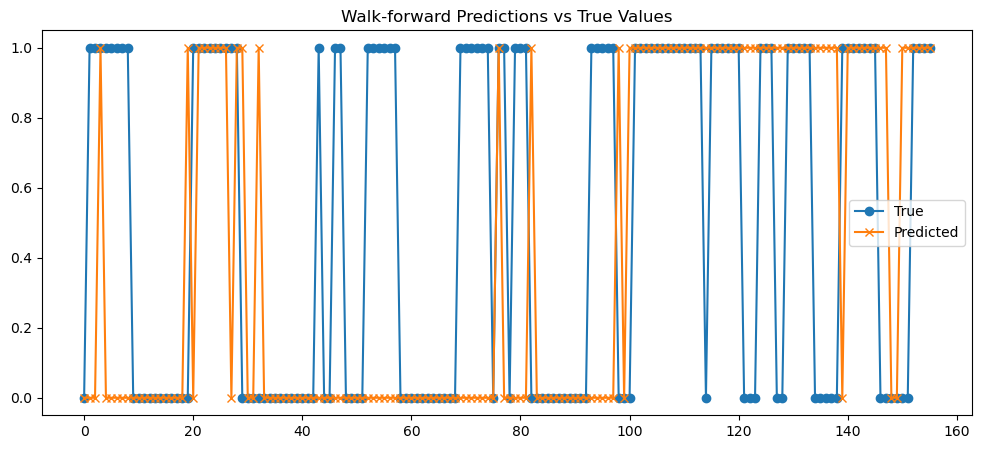

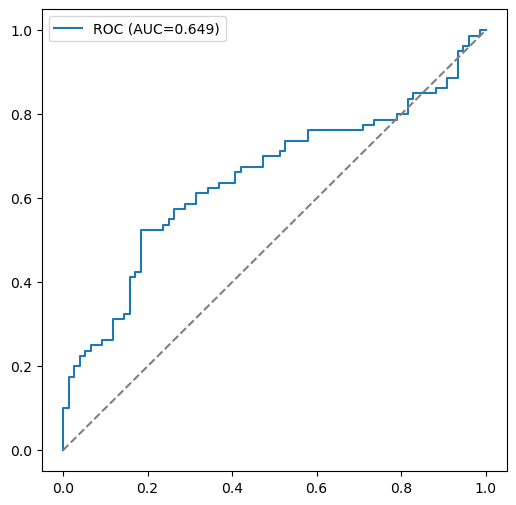

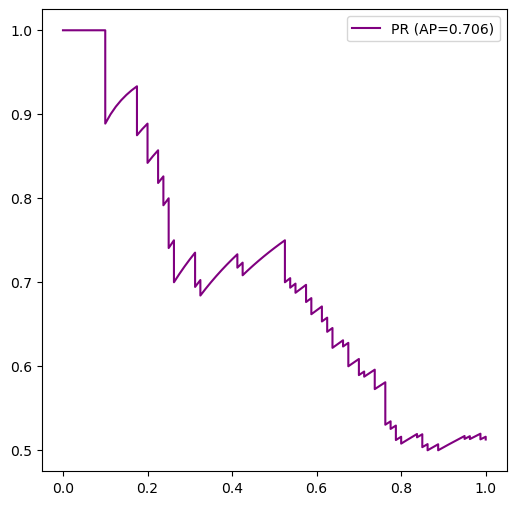

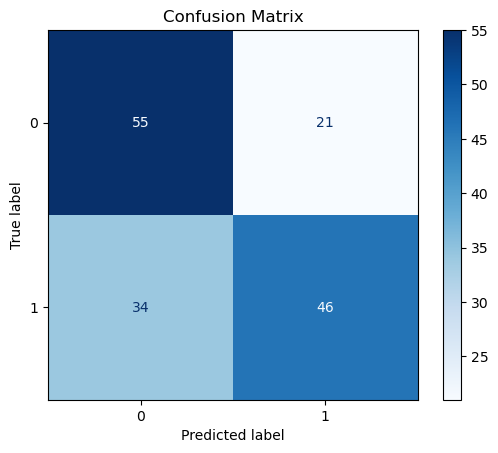


=== ADAPTIVE PARAMS RESULTS ===
Walk-forward Performance:
Accuracy : 0.647
F1 Score : 0.631
Recall   : 0.588
Precision: 0.681
ROC AUC  : 0.656
PR  AUC  : 0.709


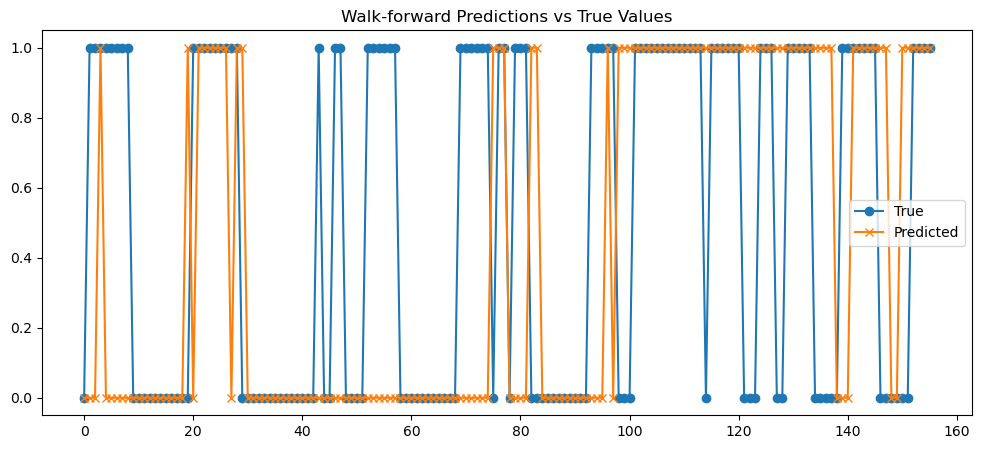

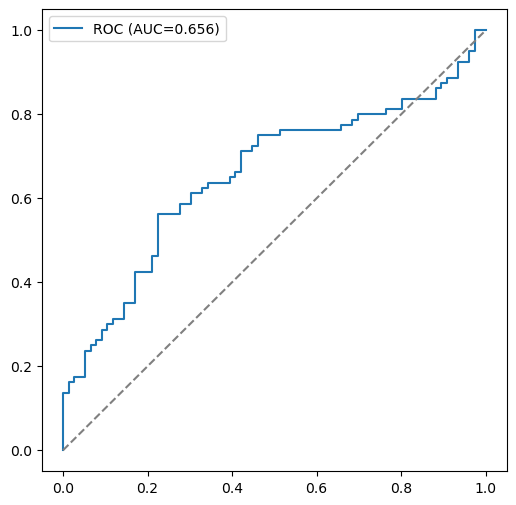

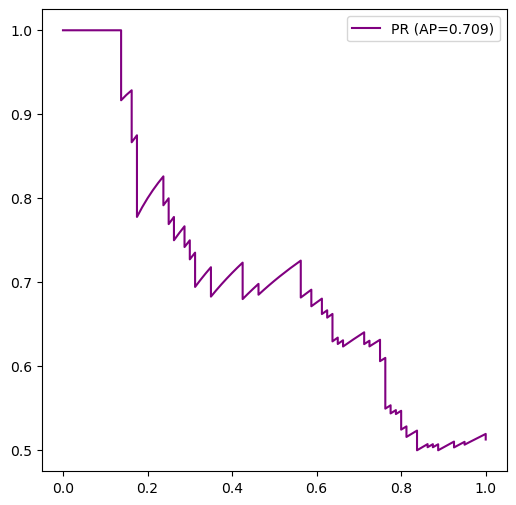

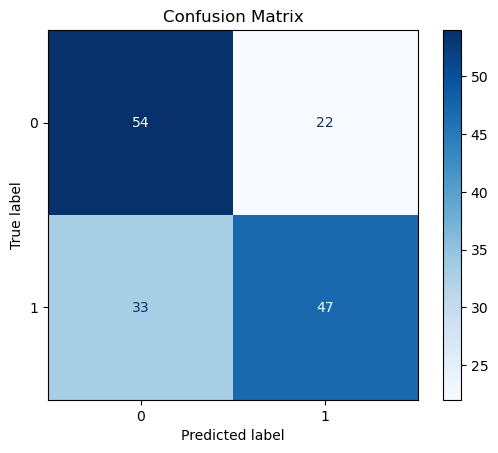

In [8]:

def main():
    # Data prep:
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Replace NaN/inf values
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === PHASE 1: HYPERPARAMETER TUNING ===
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X_scaled, y)

    # === PHASE 2: FINAL EVALUATION ===
    print("\n=== PHASE 2: FINAL EVALUATION ===")

    # --- Fixed parameters (no retuning) ---
    actuals_fixed, preds_fixed, probs_fixed = walk_forward_validation(
        X_scaled, y, n_test=FINAL_TEST_POINTS, base_params=best_params, retune_every=None
    )

    # --- Adaptive parameters (re-tune every N steps) ---
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X_scaled, y, n_test=FINAL_TEST_POINTS, base_params=best_params, retune_every=12
    )

    # === PHASE 3: PERFORMANCE & PLOTS ===
    print("\n=== FIXED PARAMS RESULTS ===")
    display_walkforward_results(actuals_fixed, preds_fixed, probs_fixed)

    print("\n=== ADAPTIVE PARAMS RESULTS ===")
    display_walkforward_results(actuals_adapt, preds_adapt, probs_adapt)

    # Return all results for downstream use
    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "fixed": (actuals_fixed, preds_fixed, probs_fixed),
        "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    }


# === Execute pipeline ===
if __name__ == "__main__":
    results = main()
